# Assignment #1

**Janin Janowski, Florian Robrecht, Anna Hartmann**

---

## Datasets

**Dataset 1:** Kaggle Pokémon Dataset  
https://www.kaggle.com/datasets/rounakbanik/pokemon/  

**Dataset 2:** Satellite Dataset  

---

## Introduction

We use two datasets to highlight how dimensionality reduction behaves in different settings: a simpler tabular dataset (Pokémon) and a more complex image dataset (satellite data).

The Pokémon dataset consists of engineered features, such as type interactions and manually constructed attributes. These features do not naturally lie in a geometric space, meaning that Euclidean distances between data points are less meaningful. The task is to classify whether a Pokémon is legendary or not. Legendary Pokémon are rare, powerful entities within the Pokémon universe, typically unique, non-evolving, and associated with specific in-game events or lore.

In contrast, the satellite dataset consists of image-based data, where each observation is represented as pixel intensities. These features inherently form a geometric structure in Euclidean space, where distances between points reflect visual similarity. Therefore, dimensionality reduction techniques such as random projection are expected to better preserve meaningful structure in this setting.

In [1]:
# import general libraries
import pandas as pd
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt

# import sklearn libraries 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.random_projection import SparseRandomProjection, johnson_lindenstrauss_min_dim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 

## 1. Pokémon Dataset

In [2]:
# load pokemon dataset
path = kagglehub.dataset_download("rounakbanik/pokemon")
df = pd.read_csv(os.path.join(path, "pokemon.csv"))

In [3]:
# Exploratory Data Analysis (EDA)

# First look
pd.set_option('display.max_columns', None)
display(df.head())
pd.reset_option('display.max_columns')

# Check size 
display(df.shape)

# Columns
display(df.columns)

# Data types
display(df.info())

# Missing values in %
display((df.isna().sum() / len(df)) * 100)

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1.0,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2.0,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,NaN,19.0,1,0


(801, 41)

Index(['abilities', 'against_bug', 'against_dark', 'against_dragon',
       'against_electric', 'against_fairy', 'against_fight', 'against_fire',
       'against_flying', 'against_ghost', 'against_grass', 'against_ground',
       'against_ice', 'against_normal', 'against_poison', 'against_psychic',
       'against_rock', 'against_steel', 'against_water', 'attack',
       'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate',
       'classfication', 'defense', 'experience_growth', 'height_m', 'hp',
       'japanese_name', 'name', 'percentage_male', 'pokedex_number',
       'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg',
       'generation', 'is_legendary'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    str    
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non-null    fl

None

abilities             0.000000
against_bug           0.000000
against_dark          0.000000
against_dragon        0.000000
against_electric      0.000000
against_fairy         0.000000
against_fight         0.000000
against_fire          0.000000
against_flying        0.000000
against_ghost         0.000000
against_grass         0.000000
against_ground        0.000000
against_ice           0.000000
against_normal        0.000000
against_poison        0.000000
against_psychic       0.000000
against_rock          0.000000
against_steel         0.000000
against_water         0.000000
attack                0.000000
base_egg_steps        0.000000
base_happiness        0.000000
base_total            0.000000
capture_rate          0.000000
classfication         0.000000
defense               0.000000
experience_growth     0.000000
height_m              2.496879
hp                    0.000000
japanese_name         0.000000
name                  0.000000
percentage_male      12.234707
pokedex_

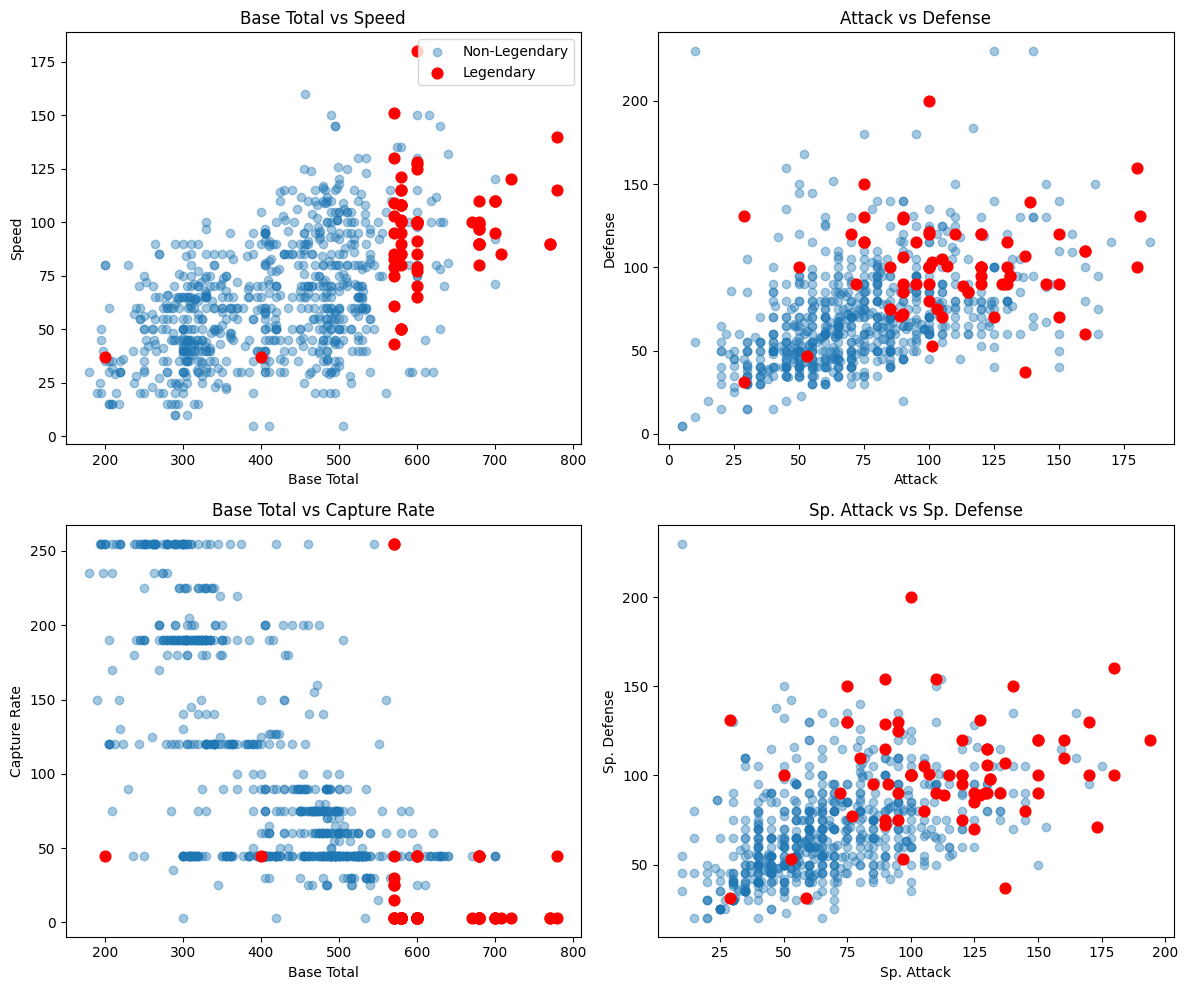

In [14]:
# Split data
legendary = df[df['is_legendary'] == 1]
non_legendary = df[df['is_legendary'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# 1. Base Total vs Speed
axes[0].scatter(non_legendary['base_total'], non_legendary['speed'], alpha=0.4, label='Non-Legendary')
axes[0].scatter(legendary['base_total'], legendary['speed'], color='red', s=60, label='Legendary')
axes[0].set_title('Base Total vs Speed')
axes[0].set_xlabel('Base Total')
axes[0].set_ylabel('Speed')
axes[0].legend()

# 2. Attack vs Defense
axes[1].scatter(non_legendary['attack'], non_legendary['defense'], alpha=0.4)
axes[1].scatter(legendary['attack'], legendary['defense'], color='red', s=60)
axes[1].set_title('Attack vs Defense')
axes[1].set_xlabel('Attack')
axes[1].set_ylabel('Defense')

# 3. Base Total vs Capture Rate
axes[2].scatter(non_legendary['base_total'], non_legendary['capture_rate'], alpha=0.4)
axes[2].scatter(legendary['base_total'], legendary['capture_rate'], color='red', s=60)
axes[2].set_title('Base Total vs Capture Rate')
axes[2].set_xlabel('Base Total')
axes[2].set_ylabel('Capture Rate')

# 4. Sp. Attack vs Sp. Defense
axes[3].scatter(non_legendary['sp_attack'], non_legendary['sp_defense'], alpha=0.4)
axes[3].scatter(legendary['sp_attack'], legendary['sp_defense'], color='red', s=60)
axes[3].set_title('Sp. Attack vs Sp. Defense')
axes[3].set_xlabel('Sp. Attack')
axes[3].set_ylabel('Sp. Defense')

plt.tight_layout()
plt.show()

In [4]:
# Cleaning

# Drop useless columns
df = df.drop(columns=[
    "abilities",
    "japanese_name",
    "name",
    "classfication"
])

# Fix data type (capture_rate is string instead of int)
df["capture_rate"] = pd.to_numeric(df["capture_rate"], errors="coerce")

# Fill type2 missing data with None, fill percentage_male, height, weight with median
df["type2"] = df["type2"].fillna("None")
df["percentage_male"] = df["percentage_male"].fillna(df["percentage_male"].median())
df["height_m"] = df["height_m"].fillna(df["height_m"].median())
df["weight_kg"] = df["weight_kg"].fillna(df["weight_kg"].median())
df["capture_rate"] = df["capture_rate"].fillna(df["capture_rate"].median())

# Encode categorical variables (type1 and type2)
df = pd.get_dummies(df, columns=["type1", "type2"], drop_first=True)

In [5]:
# Define features and target variable 
# Target: Is the pokemon legendary or not?
X = df.drop(columns=["is_legendary"])
y = df["is_legendary"]

In [6]:
# Check no missing values left and shape
# We have 801 pokemons and 69 features and no missing values left

print("Any NaNs left:", np.isnan(X).sum().sum())
print("Shape of X:", X.shape)

Any NaNs left: 0
Shape of X: (801, 69)


In [7]:
# Train/test split 
# 30% test, 70% train
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=11,
    stratify=y # same portportion of non-legendary/legendary in train and test sets
)

In [8]:
# Scale numeric features to mean = 0 and standard deviation = 1, keep boolean features as is (0/1)

print("Before scaling:")
print(X.head())

# Separate column types
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
bool_cols = X.select_dtypes(include=['bool']).columns

# Convert bool → int (0/1)
X[bool_cols] = X[bool_cols].astype(int)

# Scale numeric columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("\nAfter scaling:")
print(X.head())

Before scaling:
   against_bug  against_dark  against_dragon  against_electric  against_fairy  \
0          1.0           1.0             1.0               0.5            0.5   
1          1.0           1.0             1.0               0.5            0.5   
2          1.0           1.0             1.0               0.5            0.5   
3          0.5           1.0             1.0               1.0            0.5   
4          0.5           1.0             1.0               1.0            0.5   

   against_fight  against_fire  against_flying  against_ghost  against_grass  \
0            0.5           2.0             2.0            1.0           0.25   
1            0.5           2.0             2.0            1.0           0.25   
2            0.5           2.0             2.0            1.0           0.25   
3            1.0           0.5             1.0            1.0           0.50   
4            1.0           0.5             1.0            1.0           0.50   

   ...  type2_gh

In [9]:
# Johnson-Lindenstrauss bound
# This is only a theoretical distance-preservation bound/ worst-case theoretical guarantee, not a classification optimum
# If you want to preserve all pairwise distances between points with very small error (ε=0.1), then you may need a high dimension (5730 dimensions for 801 samples)
jl_bound = johnson_lindenstrauss_min_dim(n_samples=X.shape[0], eps=0.1)
print(f"Johnson-Lindenstrauss lower bound for eps=0.1: k >= {jl_bound} given n={X.shape[0]} samples")

Johnson-Lindenstrauss lower bound for eps=0.1: k >= 5730 given n=801 samples


In [10]:
# Class distribution in target variable 
# Majority-class baseline accuracy (~91%) for comparison 
# unbalanced classes (801 pokemons, 70 legendary → 731 non-legendary)
print(y.value_counts(normalize=True))

is_legendary
0    0.912609
1    0.087391
Name: proportion, dtype: float64


Baseline accuracy (original 69 dimensions): 1.0000
Tested dimensions: [ 2  6 11 16 21 25 30 35 40 45 49 54 59 64 69]


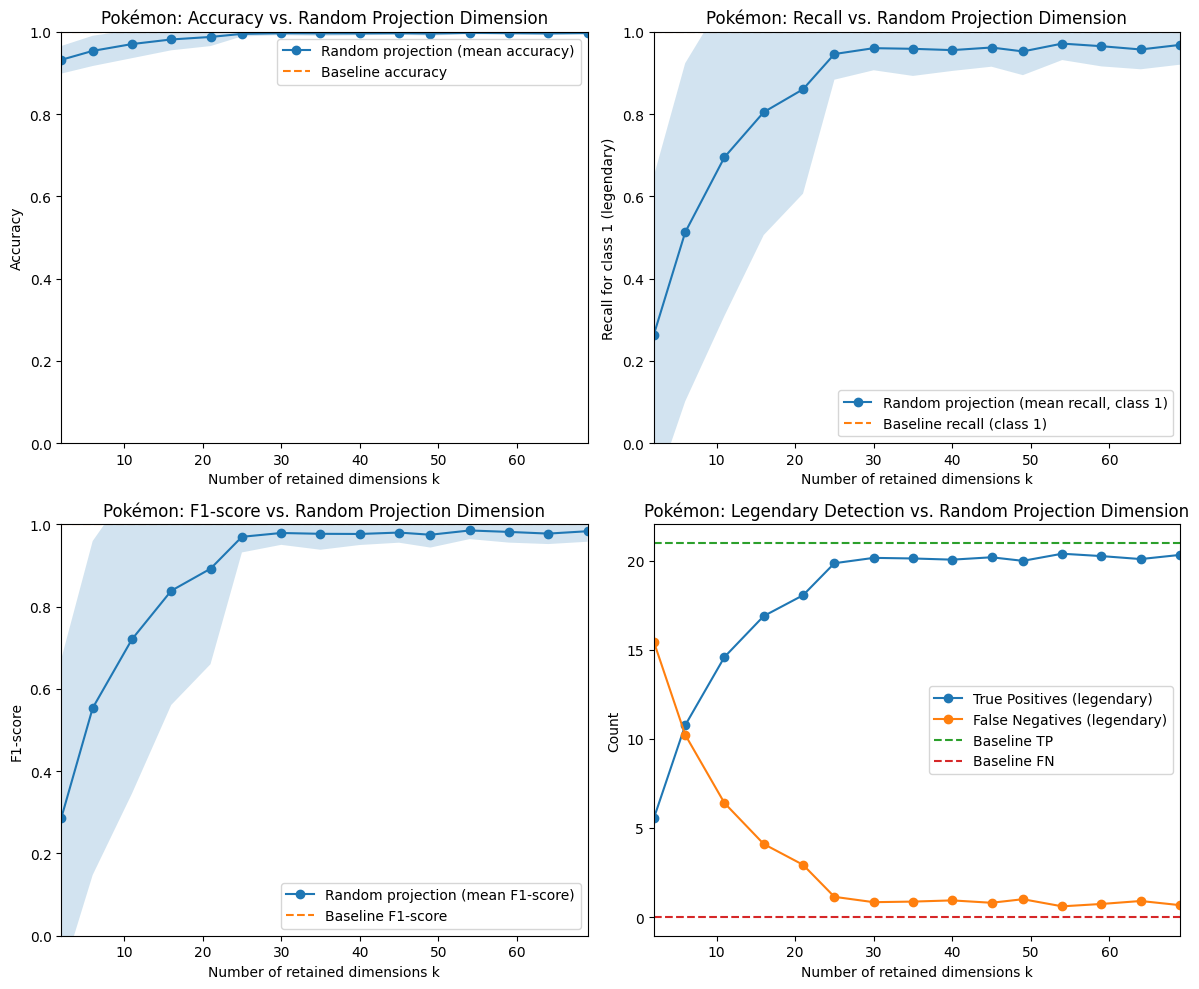


Dimension-wise results:
k= 2 | mean accuracy=0.9320 | mean recall=0.2635 | mean F1=0.2861 | mean TP=5.53 | mean FN=15.47 | acc std=0.0335
k= 6 | mean accuracy=0.9537 | mean recall=0.5127 | mean F1=0.5535 | mean TP=10.77 | mean FN=10.23 | acc std=0.0368
k=11 | mean accuracy=0.9703 | mean recall=0.6952 | mean F1=0.7206 | mean TP=14.60 | mean FN=6.40 | acc std=0.0343
k=16 | mean accuracy=0.9815 | mean recall=0.8048 | mean F1=0.8385 | mean TP=16.90 | mean FN=4.10 | acc std=0.0263
k=21 | mean accuracy=0.9876 | mean recall=0.8603 | mean F1=0.8921 | mean TP=18.07 | mean FN=2.93 | acc std=0.0222
k=25 | mean accuracy=0.9950 | mean recall=0.9460 | mean F1=0.9697 | mean TP=19.87 | mean FN=1.13 | acc std=0.0062
k=30 | mean accuracy=0.9965 | mean recall=0.9603 | mean F1=0.9790 | mean TP=20.17 | mean FN=0.83 | acc std=0.0047
k=35 | mean accuracy=0.9963 | mean recall=0.9587 | mean F1=0.9770 | mean TP=20.13 | mean FN=0.87 | acc std=0.0062
k=40 | mean accuracy=0.9961 | mean recall=0.9556 | mean F1=0.9

In [11]:
# SVM classifier draws a straight line (or hyperplane) to separate two classes

# Baseline model with 69 dimensions
baseline_model = LinearSVC(max_iter=1000, random_state=11)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

baseline_cm = confusion_matrix(y_test, baseline_pred)
baseline_fn = baseline_cm[1, 0]
baseline_tp = baseline_cm[1, 1]

print(f"Baseline accuracy (original {X.shape[1]} dimensions): {baseline_acc:.4f}")

# Dimensions to test
# [ 2  6 11 16 21 25 30 35 40 45 49 54 59 64 69]
dims = np.unique(np.linspace(2, X.shape[1], 15).astype(int))
print("Tested dimensions:", dims)

# Repeated random projections
# How often do you generate a new representation of the same data, i.e., the random matrix used for projection
realizations = 30

acc_scores = np.zeros((realizations, len(dims)))
precision_scores = np.zeros((realizations, len(dims)))
recall_scores = np.zeros((realizations, len(dims)))
f1_scores = np.zeros((realizations, len(dims)))
tp_scores = np.zeros((realizations, len(dims)))
fn_scores = np.zeros((realizations, len(dims)))

for j, dim in enumerate(dims):
    for i in range(realizations):
        rp = SparseRandomProjection(
            n_components=dim,
            random_state=i
        )

        X_train_rp = rp.fit_transform(X_train)
        X_test_rp = rp.transform(X_test)

        model = LinearSVC(max_iter=1000, random_state=11)
        model.fit(X_train_rp, y_train)

        y_pred = model.predict(X_test_rp)

        acc_scores[i, j] = accuracy_score(y_test, y_pred)
        precision_scores[i, j] = precision_score(y_test, y_pred, zero_division=0)
        recall_scores[i, j] = recall_score(y_test, y_pred, zero_division=0)
        f1_scores[i, j] = f1_score(y_test, y_pred, zero_division=0)

        cm = confusion_matrix(y_test, y_pred)
        fn_scores[i, j] = cm[1, 0]
        tp_scores[i, j] = cm[1, 1]

# Average + variability
mean_acc = acc_scores.mean(axis=0)
std_acc = acc_scores.std(axis=0)

mean_recall = recall_scores.mean(axis=0)
std_recall = recall_scores.std(axis=0)

mean_f1 = f1_scores.mean(axis=0)
std_f1 = f1_scores.std(axis=0)

mean_tp = tp_scores.mean(axis=0)
mean_fn = fn_scores.mean(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Accuracy plot
# Accuracy = (correct predictions) / (all predictions)
# Accuracy is already high due to class imbalance and quickly reaches baseline performance
axes[0].plot(dims, mean_acc, marker='o', label='Random projection (mean accuracy)')
axes[0].plot(dims, [baseline_acc] * len(dims), linestyle='--', label='Baseline accuracy')
axes[0].fill_between(dims, mean_acc - std_acc, mean_acc + std_acc, alpha=0.2) # Variability band for random projection result
axes[0].set_xlabel("Number of retained dimensions k")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Pokémon: Accuracy vs. Random Projection Dimension")
axes[0].set_xlim(dims.min(), dims.max())
axes[0].set_ylim(0, 1)
axes[0].legend()

# Recall plot
# Recall (class 1) = (correctly predicted legendary) / (all actual legendary)
# Recall improves strongly with k, showing fewer missed legendary Pokémon as dimensions increase
axes[1].plot(dims, mean_recall, marker='o', label='Random projection (mean recall, class 1)')
axes[1].plot(dims, [baseline_recall] * len(dims), linestyle='--', label='Baseline recall (class 1)')
axes[1].fill_between(dims, mean_recall - std_recall, mean_recall + std_recall, alpha=0.2)
axes[1].set_xlabel("Number of retained dimensions k")
axes[1].set_ylabel("Recall for class 1 (legendary)")
axes[1].set_title("Pokémon: Recall vs. Random Projection Dimension")
axes[1].set_xlim(dims.min(), dims.max())
axes[1].set_ylim(0, 1)
axes[1].legend()

# F1-score plot
# F1-score = balance between precision and recall (high only if both are high)
# Precision = (correctly predicted legendary) / (all predicted legendary)
# F1-score follows recall and stabilizes around k ≈ 25–30, indicating balanced performance
axes[2].plot(dims, mean_f1, marker='o', label='Random projection (mean F1-score)')
axes[2].plot(dims, [baseline_f1] * len(dims), linestyle='--', label='Baseline F1-score')
axes[2].fill_between(dims, mean_f1 - std_f1, mean_f1 + std_f1, alpha=0.2)
axes[2].set_xlabel("Number of retained dimensions k")
axes[2].set_ylabel("F1-score")
axes[2].set_title("Pokémon: F1-score vs. Random Projection Dimension")
axes[2].set_xlim(dims.min(), dims.max())
axes[2].set_ylim(0, 1)
axes[2].legend()

# Confusion Matrix: TP / FN plot for class 1
# TP = correctly predicted legendary, FN = legendary predicted as non-legendary
# True positives increase and false negatives decrease with k, stabilizing near baseline after ~25 dimensions
axes[3].plot(dims, mean_tp, marker='o', label='True Positives (legendary)')
axes[3].plot(dims, mean_fn, marker='o', label='False Negatives (legendary)')
axes[3].plot(dims, [baseline_tp] * len(dims), linestyle='--', label='Baseline TP')
axes[3].plot(dims, [baseline_fn] * len(dims), linestyle='--', label='Baseline FN')
axes[3].set_xlabel("Number of retained dimensions k")
axes[3].set_ylabel("Count")
axes[3].set_title("Pokémon: Legendary Detection vs. Random Projection Dimension")
axes[3].set_xlim(dims.min(), dims.max())
axes[3].legend()

plt.tight_layout()
plt.show()

# Print table results
print("\nDimension-wise results:")
for dim, acc, rec, f1, tp, fn, sd_acc in zip(dims, mean_acc, mean_recall, mean_f1, mean_tp, mean_fn, std_acc):
    print(
        f"k={dim:2d} | "
        f"mean accuracy={acc:.4f} | "
        f"mean recall={rec:.4f} | "
        f"mean F1={f1:.4f} | "
        f"mean TP={tp:.2f} | "
        f"mean FN={fn:.2f} | "
        f"acc std={sd_acc:.4f}"
    )

Baseline accuracy (original 69 dimensions): 1.0000
Tested dimensions: [ 2  6 11 16 21 25 30 35 40 45 49 54 59 64 69]
Running experiment with 5 random projections per dimension...
Running experiment with 10 random projections per dimension...
Running experiment with 30 random projections per dimension...
Running experiment with 100 random projections per dimension...


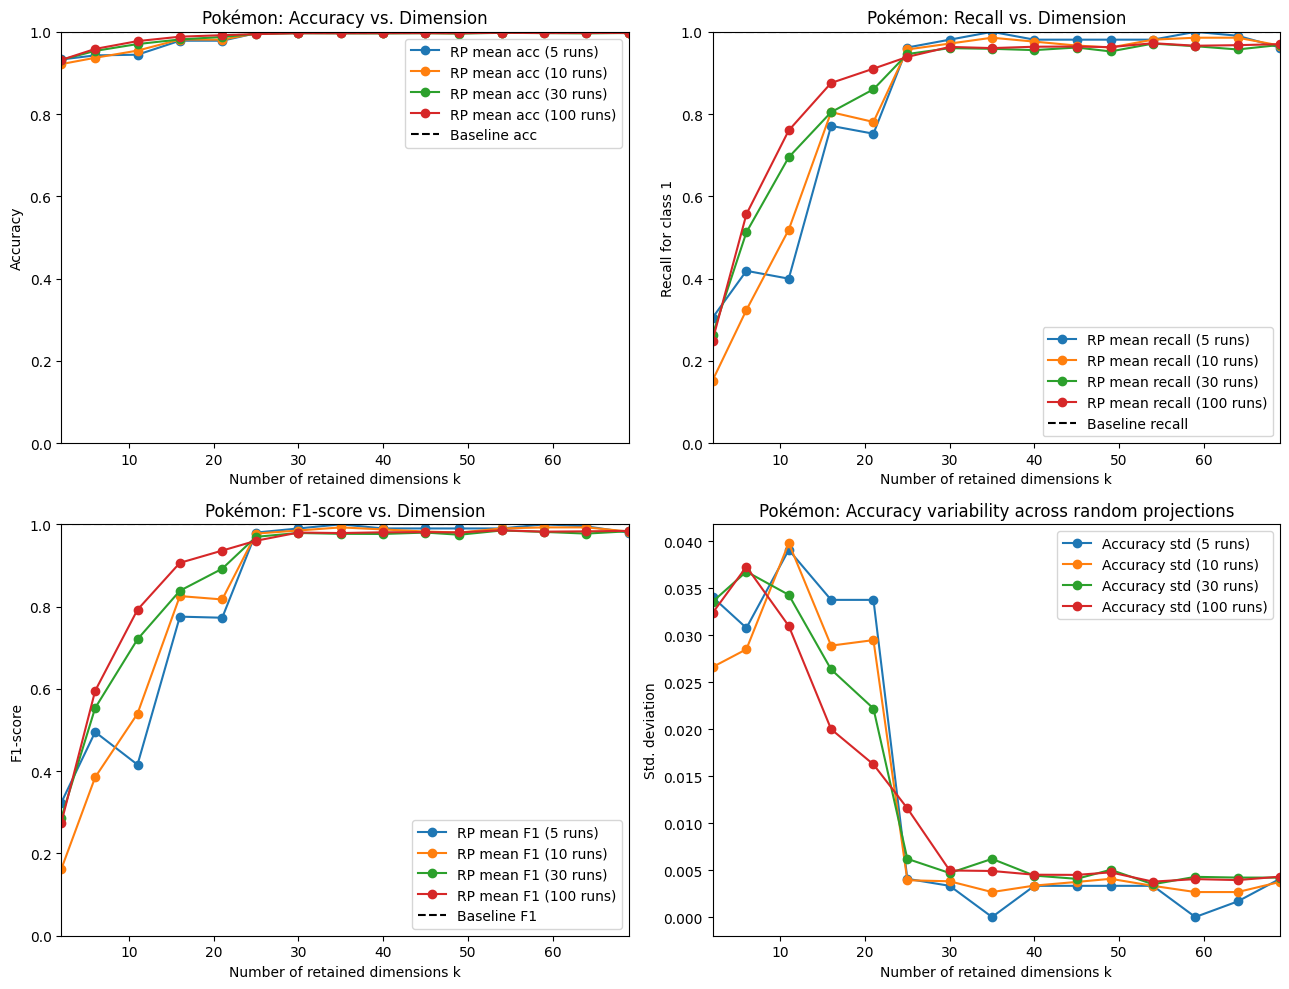


Results averaged over 5 random projections:
k= 2 | mean accuracy=0.9328 | mean recall=0.3048 | mean F1=0.3234 | mean TP=6.40 | mean FN=14.60 | acc std=0.0341
k= 6 | mean accuracy=0.9427 | mean recall=0.4190 | mean F1=0.4952 | mean TP=8.80 | mean FN=12.20 | acc std=0.0308
k=11 | mean accuracy=0.9444 | mean recall=0.4000 | mean F1=0.4158 | mean TP=8.40 | mean FN=12.60 | acc std=0.0391
k=16 | mean accuracy=0.9784 | mean recall=0.7714 | mean F1=0.7756 | mean TP=16.20 | mean FN=4.80 | acc std=0.0338
k=21 | mean accuracy=0.9784 | mean recall=0.7524 | mean F1=0.7730 | mean TP=15.80 | mean FN=5.20 | acc std=0.0338
k=25 | mean accuracy=0.9967 | mean recall=0.9619 | mean F1=0.9800 | mean TP=20.20 | mean FN=0.80 | acc std=0.0041
k=30 | mean accuracy=0.9983 | mean recall=0.9810 | mean F1=0.9900 | mean TP=20.60 | mean FN=0.40 | acc std=0.0033
k=35 | mean accuracy=1.0000 | mean recall=1.0000 | mean F1=1.0000 | mean TP=21.00 | mean FN=0.00 | acc std=0.0000
k=40 | mean accuracy=0.9983 | mean recall=0

In [ ]:
# Baseline model on original data
baseline_model = LinearSVC(max_iter=1000, random_state=11)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

baseline_cm = confusion_matrix(y_test, baseline_pred)
baseline_fn = baseline_cm[1, 0]
baseline_tp = baseline_cm[1, 1]

print(f"Baseline accuracy (original {X.shape[1]} dimensions): {baseline_acc:.4f}")

# Dimensions to test
dims = np.unique(np.linspace(2, X.shape[1], 15).astype(int))
print("Tested dimensions:", dims)

# Different numbers of random projections to compare
realization_list = [5, 10, 30, 100]


def run_random_projection_experiment(X_train, X_test, y_train, y_test, dims, realizations):
    """
    Run repeated sparse random projection experiments for a given number
    of realizations and return averaged metrics.
    """
    acc_scores = np.zeros((realizations, len(dims)))
    precision_scores = np.zeros((realizations, len(dims)))
    recall_scores = np.zeros((realizations, len(dims)))
    f1_scores = np.zeros((realizations, len(dims)))
    tp_scores = np.zeros((realizations, len(dims)))
    fn_scores = np.zeros((realizations, len(dims)))

    for j, dim in enumerate(dims):
        for i in range(realizations):
            rp = SparseRandomProjection(
                n_components=dim,
                random_state=i
            )

            X_train_rp = rp.fit_transform(X_train)
            X_test_rp = rp.transform(X_test)

            model = LinearSVC(max_iter=1000, random_state=11)
            model.fit(X_train_rp, y_train)
            y_pred = model.predict(X_test_rp)

            acc_scores[i, j] = accuracy_score(y_test, y_pred)
            precision_scores[i, j] = precision_score(y_test, y_pred, zero_division=0)
            recall_scores[i, j] = recall_score(y_test, y_pred, zero_division=0)
            f1_scores[i, j] = f1_score(y_test, y_pred, zero_division=0)

            cm = confusion_matrix(y_test, y_pred)
            fn_scores[i, j] = cm[1, 0]
            tp_scores[i, j] = cm[1, 1]

    results = {
        "mean_acc": acc_scores.mean(axis=0),
        "std_acc": acc_scores.std(axis=0),
        "mean_precision": precision_scores.mean(axis=0),
        "std_precision": precision_scores.std(axis=0),
        "mean_recall": recall_scores.mean(axis=0),
        "std_recall": recall_scores.std(axis=0),
        "mean_f1": f1_scores.mean(axis=0),
        "std_f1": f1_scores.std(axis=0),
        "mean_tp": tp_scores.mean(axis=0),
        "mean_fn": fn_scores.mean(axis=0),
    }
    return results


# Run experiments for different realization counts
all_results = {}

for R in realization_list:
    print(f"Running experiment with {R} random projections per dimension...")
    all_results[R] = run_random_projection_experiment(
        X_train, X_test, y_train, y_test, dims, R
    )

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

# Accuracy
for R in realization_list:
    axes[0].plot(dims, all_results[R]["mean_acc"], marker='o', label=f'RP mean acc ({R} runs)')
axes[0].plot(dims, [baseline_acc] * len(dims), linestyle='--', color='black', label='Baseline acc')
axes[0].set_xlabel("Number of retained dimensions k")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Pokémon: Accuracy vs. Dimension")
axes[0].set_xlim(dims.min(), dims.max())
axes[0].set_ylim(0, 1)
axes[0].legend()

# Recall
for R in realization_list:
    axes[1].plot(dims, all_results[R]["mean_recall"], marker='o', label=f'RP mean recall ({R} runs)')
axes[1].plot(dims, [baseline_recall] * len(dims), linestyle='--', color='black', label='Baseline recall')
axes[1].set_xlabel("Number of retained dimensions k")
axes[1].set_ylabel("Recall for class 1")
axes[1].set_title("Pokémon: Recall vs. Dimension")
axes[1].set_xlim(dims.min(), dims.max())
axes[1].set_ylim(0, 1)
axes[1].legend()

# F1
for R in realization_list:
    axes[2].plot(dims, all_results[R]["mean_f1"], marker='o', label=f'RP mean F1 ({R} runs)')
axes[2].plot(dims, [baseline_f1] * len(dims), linestyle='--', color='black', label='Baseline F1')
axes[2].set_xlabel("Number of retained dimensions k")
axes[2].set_ylabel("F1-score")
axes[2].set_title("Pokémon: F1-score vs. Dimension")
axes[2].set_xlim(dims.min(), dims.max())
axes[2].set_ylim(0, 1)
axes[2].legend()

# Standard deviation of accuracy
for R in realization_list:
    axes[3].plot(dims, all_results[R]["std_acc"], marker='o', label=f'Accuracy std ({R} runs)')
axes[3].set_xlabel("Number of retained dimensions k")
axes[3].set_ylabel("Std. deviation")
axes[3].set_title("Pokémon: Accuracy variability across random projections")
axes[3].set_xlim(dims.min(), dims.max())
axes[3].legend()

plt.tight_layout()
plt.show()

# Print summary tables
for R in realization_list:
    print(f"\nResults averaged over {R} random projections:")
    for dim, acc, rec, f1, tp, fn, sd_acc in zip(
        dims,
        all_results[R]["mean_acc"],
        all_results[R]["mean_recall"],
        all_results[R]["mean_f1"],
        all_results[R]["mean_tp"],
        all_results[R]["mean_fn"],
        all_results[R]["std_acc"]
    ):
        print(
            f"k={dim:2d} | "
            f"mean accuracy={acc:.4f} | "
            f"mean recall={rec:.4f} | "
            f"mean F1={f1:.4f} | "
            f"mean TP={tp:.2f} | "
            f"mean FN={fn:.2f} | "
            f"acc std={sd_acc:.4f}"
        )

## 2. Satellite Dataset

## Take-Home Message

**Initial Question:**  
How does classification performance change when we reduce dimensionality using random projections?

**Findings:**  
The results show that classification performance is largely preserved even after substantial dimensionality reduction.

For the Pokémon dataset, very low dimensions lead to a loss in recall for the minority class (legendary Pokémon). However, performance stabilizes around **25–30 dimensions**. Beyond this point, additional dimensions provide negligible improvements, indicating redundancy in the original feature space.
